## Evaluation

### What each later cell does

- **Module 0 — Setup & path**
  - Set `cwd` to project root and add it to `sys.path` so `from src...` imports work.

- **Module 1 — Initialize RAG engine**
  - Create `rag = RAGEngine(...)` (loads chunks + initializes lexical retriever + generates neural embeddings).

- **Module 2 — Retrieval sanity check (Q1)**
  - Print **lexical** retrieved context.
  - Print **neural** retrieved context (with similarity).
  - Print a quick `compare_retrievers(...)` summary.

- **Module 3 Evaluation — Core helper functions**
  - Define shared utilities used by all comparisons: token estimation, retrieval, summarization, generation (no-RAG / RAG-with-citations), judging (`judge_pairwise`), and `overall_accuracy`.

- **Representative queries (Q1–Q3)**
  - Define the 3 evaluation questions and build `queries = [(label, query), ...]`.

- **Comparison 1 — No-RAG vs Neural RAG**
  - For each query: Answer A = **no context**; Answer B = **neural retrieved context + citations**.
  - Judge A vs B and output a compact metrics list.

- **Comparison 2 — Lexical RAG vs Neural RAG**
  - For each query: Answer A = **lexical context + citations**; Answer B = **neural context + citations**.
  - Judge A vs B and also save `results` (including `lex_ctx`/`neu_ctx`) for visualization.

- **Comparison 3 — Raw vs Summarized context (Neural)**
  - For each query: Answer A = **raw neural context**; Answer B = **summarized neural context**.
  - Judge A vs B and report token reduction vs quality trade-off.

- **Visualization — Wordcloud (Q1 example)**
  - Use `results[0]` to plot **two wordclouds** (lexical vs neural). If `wordcloud` is missing, fall back to a bar chart.

- **Quality, Token-usage and top_k tradeoff**
  - Run `evaluate_topk_quality_token_tradeoff(...)` across multiple `top_k` values.
  - Plot **quality vs top_k**, **quality vs token-usage** and **token-usage vs top_k**.

### Notes

- If you see `parse_error` in judge outputs, it means the judge returned non-valid JSON (truncation or formatting); the notebook will continue running and record the raw output for inspection.
- For stability on limited RAM/VRAM, prefer smaller models (e.g. `gemma3:1b`) and keep `num_ctx` modest.


## Module 0 — Setup

Set the working directory to the project root so imports like `from src.rag_engine import RAGEngine` work reliably.

In [98]:
import os, sys

os.chdir(r"e:\HKBU\COMP7125 Prompt Engineering\lab\HKBU_Study_Companion-main\HKBU_Study_Companion-main")
sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: e:\HKBU\COMP7125 Prompt Engineering\lab\HKBU_Study_Companion-main\HKBU_Study_Companion-main


## Module 1 — Initialize RAG engine

Loads pre-chunked documents from `output/chunks_sliding_500_50.jsonl`, then builds:
- **Lexical retriever** (keyword overlap)
- **Neural retriever** (Ollama embeddings + cosine similarity)

This step can take a few minutes the first time because embeddings are generated for all chunks.

In [99]:
from src.rag_engine import RAGEngine
rag = RAGEngine(chunk_file='chunks_natural_500_50.jsonl')


🚀 Initializing RAG Engine with chunk file: chunks_natural_500_50.jsonl
✅ Loaded 377 chunks from chunks_natural_500_50.jsonl
📚 Initializing Lexical Retriever...
🧠 Initializing Neural Retriever...
🔄 Generating embeddings for 377 chunks (may take a few minutes)...
  Processed 50/377 chunks
  Processed 100/377 chunks
  Processed 150/377 chunks
  Processed 200/377 chunks
  Processed 250/377 chunks
  Processed 300/377 chunks
  Processed 350/377 chunks
✅ Embedding generation complete!
✅ RAG Engine ready!


## Module 2 — Retrieval sanity check (lexical vs neural)

Run one representative query and inspect the retrieved context snippets. This is a quick qualitative check before doing judge-based evaluation.

In [100]:
context, chunks = rag.lexical_search('What is HKBU policy on using GenAI?', top_k=3)
print(context)

[1] Source: data/GenAI-AdvisoryGuidelines-Students.pdf (Page 1)
Content: CONFIDENTIAL – For Internal Use Only 
 
Advisory Guidelines Pertaining to the 
Use of Generative AI Tools in Assessed Assignment Tasks 
Summer 2025 | Summarised Version 
Purpose 
These guidelines align with HKBU’s University-wide Principles for the Use of Generative AI 
Tools in Teaching and Learning, and Assessment . They support ethical, transparent, and 
effective use of GenAI tools in assessed assignments, while upholding academic integrity and...

[2] Source: data/Learning_and_Teaching_Strategy.pdf (Page 3)
Content: 9.3. provide timely and contextualised feedback to students on their learning process and outcomes, 
facilitating them to adjust their learning progress to maximise learning experience. 
 
Area 4 - Inclusive Admission for Diversity 
10. Diversity and inclusion are enhanced across the University community. An inclusive admission policy 
enables all deserving students to receive education at HKBU, c

In [101]:
context, chunks = rag.neural_search('What is HKBU policy on using GenAI?', top_k=3)
print(context)

[1] Source: data/COMP7055.pdf (Page 2) | Similarity: 0.6279
Content: required to develop an application prototype using an API, such as...

[2] Source: data/COMP7170.pdf (Page 2) | Similarity: 0.6139
Content: tools in different use cases via laboratories.
11. ASSESSMENT METHODS (AMs)...

[3] Source: data/GenAI-AdvisoryGuidelines-Students.pdf (Page 2) | Similarity: 0.6053
Content: Academic Integrity and Misuse 
Improper uses include: 
• Presenting AI-generated work as one’s own 
• Editing AI-created images or content without disclosure. 
Suspected misuse will be handled under existing academic integrity guidelines. Instructors may 
request, for example: 
• AI usage records 
• Early draft versions 
• Oral explanation of the work. 
AI detection tools may support, but not replace, professional academic judgment. Instructors...


In [102]:
result = rag.compare_retrievers('What is HKBU policy on using GenAI?', top_k=3)
print(result)

{'query': 'What is HKBU policy on using GenAI?', 'lexical': {'context': '[1] Source: data/GenAI-AdvisoryGuidelines-Students.pdf (Page 1)\nContent: CONFIDENTIAL – For Internal Use Only \n \nAdvisory Guidelines Pertaining to the \nUse of Generative AI Tools in Assessed Assignment Tasks \nSummer 2025 | Summarised Version \nPurpose \nThese guidelines align with HKBU’s University-wide Principles for the Use of Generative AI \nTools in Teaching and Learning, and Assessment . They support ethical, transparent, and \neffective use of GenAI tools in assessed assignments, while upholding academic integrity and...\n\n[2] Source: data/Learning_and_Teaching_Strategy.pdf (Page 3)\nContent: 9.3. provide timely and contextualised feedback to students on their learning process and outcomes, \nfacilitating them to adjust their learning progress to maximise learning experience. \n \nArea 4 - Inclusive Admission for Diversity \n10. Diversity and inclusion are enhanced across the University community. An i

## Evaluation

In [103]:
import json
import re
import ollama

from src.prompt_manager import PromptManager
from src.chat_logic import ChatLogic

# ---- Config  ----
# ChatLogic currently uses ollama.generate(model="gemma3:4b") internally.
GEN_MODEL = "gemma3:4b"        # generation model (used for no-RAG and custom prompts)
JUDGE_MODEL = "gemma3:4b"      # judge model (stronger, more reliable scoring)

pm = PromptManager()
chat = ChatLogic(rag, pm)


def approx_tokens_from_chars(s: str) -> int:
    return max(1, int(len(s) / 4))


def retrieve_context(rag, retriever: str, query: str, top_k: int, max_chars: int = 2000):
    if retriever == "lexical":
        ctx, chunks = rag.lexical_search(query, top_k=top_k)
    elif retriever == "neural":
        ctx, chunks = rag.neural_search(query, top_k=top_k)
    else:
        raise ValueError("retriever must be 'lexical' or 'neural'")
    return ctx[:max_chars], chunks


def answer_no_rag(query: str, model: str = GEN_MODEL, num_predict: int = 600):
    # Match evaluation_basic.py style: use ollama.generate + real token counts.
    prompt = f"You are HKBU Study Companion.\nUser: {query}\nAssistant: "
    r = ollama.generate(
        model=model,
        prompt=prompt,
        options={"temperature": 0.0, "num_predict": num_predict},
    )
    return {
        "response": r.get("response", "").strip(),
        "prompt_tokens": r.get("prompt_eval_count", 0),
        "completion_tokens": r.get("eval_count", 0),
        "total_tokens": r.get("prompt_eval_count", 0) + r.get("eval_count", 0),
    }


def answer_rag_via_chat(query: str, retrieval_type: str, top_k: int = 3):
    return chat.process_query(query, retrieval_type=retrieval_type, top_k=top_k)


def summarize_context(ctx: str, model: str = GEN_MODEL, num_predict: int = 200):
    # Keep this as an optional token-efficiency technique.
    prompt = f"""Summarize the key facts from the context for answering the user question.
Return 5-8 bullet points.

[CONTEXT]
{ctx}
"""
    r = ollama.generate(
        model=model,
        prompt=prompt,
        options={"temperature": 0.0, "num_predict": num_predict},
    )
    return r.get("response", "").strip(), (r.get("prompt_eval_count", 0) + r.get("eval_count", 0))


def answer_with_context_via_pm(query: str, ctx: str, history=None, mode: str = "qa"):
    # Use the same prompt assembly strategy as basic.
    prompt = pm.assemble_prompt(query=query, context_str=ctx, history=(history or []), mode=mode)
    r = ollama.generate(
        model=GEN_MODEL,
        prompt=prompt,
        options={"temperature": 0.0 if mode == "qa" else 0.7, "num_predict": 800, "top_p": 0.9, "top_k": 40},
    )
    return {
        "response": r.get("response", "").strip(),
        "total_tokens": r.get("prompt_eval_count", 0) + r.get("eval_count", 0),
    }


def answer_with_rag_and_citations(query: str, ctx: str, model: str = GEN_MODEL):
    # Backwards-compatible wrapper (older cells may still call this name).
    # Uses the basic framework prompt assembly + ollama.generate.
    return answer_with_context_via_pm(query, ctx, history=[], mode="qa")["response"]


def judge_pairwise(query: str, answer_a: str, answer_b: str, model: str = JUDGE_MODEL, num_ctx: int = 1024, num_predict: int = 512):
    prompt = f"""You are an impartial judge.

User question:
{query}

Compare two answers.

[ANSWER A]
{answer_a}

[ANSWER B]
{answer_b}

Score EACH answer (1-5) on:
- correctness
- grounding (no unsupported claims)
- specificity
- conciseness

Return JSON only with schema:
{{
  "A": {{"correctness": <int>, "grounding": <int>, "specificity": <int>, "conciseness": <int>}},
  "B": {{"correctness": <int>, "grounding": <int>, "specificity": <int>, "conciseness": <int>}},
  "winner": "A"|"B"|"Tie",
  "reasons": ["<reason1>","<reason2>","<reason3>"]
}}
"""
    r = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        format="json",
        options={"temperature": 0, "num_ctx": num_ctx, "num_predict": num_predict},
        keep_alive=0,
    )
    text = r["message"]["content"].strip()
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{[\s\S]*\}", text)
        if not m:
            return {"parse_error": True, "raw": text}
        candidate = m.group(0)
        try:
            return json.loads(candidate)
        except Exception:
            return {"parse_error": True, "raw": text, "raw_candidate": candidate}


def overall_accuracy(score_dict: dict):
    try:
        s = [
            int(score_dict["correctness"]),
            int(score_dict["grounding"]),
            int(score_dict["specificity"]),
            int(score_dict["conciseness"]),
        ]
        return sum(s) / 4.0
    except Exception:
        return None


### Comparison 1 — No-RAG vs Neural RAG

- **Goal**: quantify the benefit of adding retrieved context.
- **Setup**: Answer A = direct LLM answer (**no context**); Answer B = **neural retriever** context + citation-style answer.
- **Output**: per query, print both answers + judge JSON, and a compact metrics list (overall_accuracy + winner).

In [104]:
# ---- Representative queries ----
Q1 = "What is the group registration deadline for COMP4146?"
Q2 = "What is the late submission policy?"
Q3 = "Help me make a 2-week study plan for the Prompt Engineering final project while taking 3 courses."

queries = [
    ("Q1", Q1),
    ("Q2", Q2),
    ("Q3", Q3),
]

queries

[('Q1', 'What is the group registration deadline for COMP4146?'),
 ('Q2', 'What is the late submission policy?'),
 ('Q3',
  'Help me make a 2-week study plan for the Prompt Engineering final project while taking 3 courses.')]

In [105]:
# ---- No-RAG vs Neural RAG ----

no_rag_vs_neural_rag = []

for label, query in queries:
    print("\n" + "=" * 80)
    print(f"{label}: {query}")
    print("=" * 80)

    # No-RAG (ollama.generate) + real token counts
    no_rag = answer_no_rag(query)

    # RAG Neural (ChatLogic unified interface)
    rag_neu = answer_rag_via_chat(query, retrieval_type="neural", top_k=3)

    print("\n=== ANSWER A (no-RAG) ===\n", no_rag["response"])
    print(f"No-RAG tokens: {no_rag['total_tokens']}")

    print("\n=== ANSWER B (RAG-Neural) ===\n", rag_neu["response"])
    print(f"RAG-Neural tokens: {rag_neu['total_tokens']} | Cited: {rag_neu['cited_docs'][:2]}...")

    # Judge
    verdict = judge_pairwise(query, no_rag["response"], rag_neu["response"])
    print("\n=== JUDGE (no-RAG vs RAG-Neural) ===")
    print(verdict)

    if isinstance(verdict, dict) and not verdict.get("parse_error"):
        a = verdict.get("A", {})
        b = verdict.get("B", {})
        no_rag_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": round(overall_accuracy(a) or 0, 2) if overall_accuracy(a) is not None else None,
                "B_overall_accuracy": round(overall_accuracy(b) or 0, 2) if overall_accuracy(b) is not None else None,
                "winner": verdict.get("winner"),
                "no_rag_tokens": no_rag["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
            }
        )
    else:
        no_rag_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": None,
                "B_overall_accuracy": None,
                "winner": None,
                "no_rag_tokens": no_rag["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
                "parse_error": True,
                "raw_verdict": verdict,
            }
        )

no_rag_vs_neural_rag


Q1: What is the group registration deadline for COMP4146?

=== ANSWER A (no-RAG) ===
 Okay, let’s find that information for you!

According to the HKBU website, the group registration deadline for COMP4146 is **Friday, 17 August 2024 at 17:00 HKT**.

You can find the full course details and registration information here: [https://www.hkbu.edu.hk/comp/courses/comp4146/](https://www.hkbu.edu.hk/comp/courses/comp4146/)

Do you need any other information about COMP4146, such as the course syllabus or timetable?
No-RAG tokens: 168

=== ANSWER B (RAG-Neural) ===
 The 2025/26 teaching activity schedule includes an add-drop period from 1 – 13 September 2025 for COMP4146 [2]. The add-drop period for the 2026/27 academic year is 12 January – 24 January 2026 [1]. However, the context does not provide specific details about the group registration deadline for COMP4146.
RAG-Neural tokens: 792 | Cited: ['data/Programme Handout for DAAI.pdf', 'data/Programme Handout for DAAI.pdf']...

=== JUDGE (no-

[{'label': 'Q1',
  'A_overall_accuracy': 5.0,
  'B_overall_accuracy': 2.0,
  'winner': 'A',
  'no_rag_tokens': 168,
  'rag_neural_tokens': 792},
 {'label': 'Q2',
  'A_overall_accuracy': 4.5,
  'B_overall_accuracy': 3.0,
  'winner': 'A',
  'no_rag_tokens': 630,
  'rag_neural_tokens': 826},
 {'label': 'Q3',
  'A_overall_accuracy': 3.5,
  'B_overall_accuracy': 4.25,
  'winner': 'B',
  'no_rag_tokens': 645,
  'rag_neural_tokens': 1590}]

### Comparison 2 — Lexical RAG vs Neural RAG

- **Goal**: compare retrievers while keeping the generator the same.
- **Setup**: Answer A = **lexical** context + citations; Answer B = **neural** context + citations.
- **Output**: per query, print both answers + judge JSON, and a compact metrics list.

This cell also saves `results` (with `lex_ctx`/`neu_ctx`) for the later **Q1 wordcloud** visualization.

In [106]:
# ---- Lexical RAG vs Neural RAG (basic unified interface) ----

lexical_vs_neural_rag = []
results = []  # keep contexts for downstream wordcloud cell

for label, query in queries:
    print("\n" + "=" * 80)
    print(f"{label}: {query}")
    print("=" * 80)

    # RAG Lexical / Neural via ChatLogic
    rag_lex = answer_rag_via_chat(query, retrieval_type="lexical", top_k=3)
    rag_neu = answer_rag_via_chat(query, retrieval_type="neural", top_k=3)

    print("\n=== ANSWER A (RAG-Lexical) ===\n", rag_lex["response"])
    print(f"RAG-Lexical tokens: {rag_lex['total_tokens']} | Cited: {rag_lex['cited_docs'][:2]}...")

    print("\n=== ANSWER B (RAG-Neural) ===\n", rag_neu["response"])
    print(f"RAG-Neural tokens: {rag_neu['total_tokens']} | Cited: {rag_neu['cited_docs'][:2]}...")

    verdict = judge_pairwise(query, rag_lex["response"], rag_neu["response"])
    print("\n=== JUDGE (RAG-Lexical vs RAG-Neural) ===")
    print(verdict)

    # Save contexts for visualization (use retrievers directly to keep raw context strings)
    lex_ctx, _ = retrieve_context(rag, "lexical", query, top_k=3, max_chars=2000)
    neu_ctx, _ = retrieve_context(rag, "neural", query, top_k=3, max_chars=2000)

    results.append({"label": label, "lex_ctx": lex_ctx, "neu_ctx": neu_ctx})

    if isinstance(verdict, dict) and not verdict.get("parse_error"):
        a = verdict.get("A", {})
        b = verdict.get("B", {})
        lexical_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": round(overall_accuracy(a) or 0, 2) if overall_accuracy(a) is not None else None,
                "B_overall_accuracy": round(overall_accuracy(b) or 0, 2) if overall_accuracy(b) is not None else None,
                "winner": verdict.get("winner"),
                "rag_lexical_tokens": rag_lex["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
            }
        )
    else:
        lexical_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": None,
                "B_overall_accuracy": None,
                "winner": None,
                "rag_lexical_tokens": rag_lex["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
                "parse_error": True,
            }
        )

lexical_vs_neural_rag


Q1: What is the group registration deadline for COMP4146?

=== ANSWER A (RAG-Lexical) ===
 The 2025/26 teaching activity schedule includes an add-drop period from 1 – 13 September 2025 for COMP4146 [2]. The add-drop period for the 2026/27 academic year is 12 January – 24 January 2026 [1]. However, the context does not provide specific details about the group registration deadline for COMP4146.
RAG-Lexical tokens: 1549 | Cited: ['data/COMP7270.pdf', 'data/COMP7880.pdf']...

=== ANSWER B (RAG-Neural) ===
 The 2025/26 teaching activity schedule includes an add-drop period from 1 – 13 September 2025 for COMP4146 [2]. The add-drop period for the 2026/27 academic year is 12 January – 24 January 2026 [1]. However, the context does not provide specific details about the group registration deadline for COMP4146.
RAG-Neural tokens: 1830 | Cited: ['data/Programme Handout for DAAI.pdf', 'data/Programme Handout for DAAI.pdf']...

=== JUDGE (RAG-Lexical vs RAG-Neural) ===
{'A': {'correctness': 5, '

[{'label': 'Q1',
  'A_overall_accuracy': 4.25,
  'B_overall_accuracy': 4.25,
  'winner': 'Tie',
  'rag_lexical_tokens': 1549,
  'rag_neural_tokens': 1830},
 {'label': 'Q2',
  'A_overall_accuracy': 4.75,
  'B_overall_accuracy': 4.75,
  'winner': 'Tie',
  'rag_lexical_tokens': 1775,
  'rag_neural_tokens': 1970},
 {'label': 'Q3',
  'A_overall_accuracy': 4.5,
  'B_overall_accuracy': 3.5,
  'winner': 'A',
  'rag_lexical_tokens': 2723,
  'rag_neural_tokens': 3449}]

### Comparison 3 — Raw context vs Summarized context (Neural)

- **Goal**: test a simple context-optimization strategy.
- **Setup**: Answer A = neural retrieved **raw** context; Answer B = neural context after **summarization**.
- **Output**: per query, print both answers + judge JSON, and a compact metrics list (including token usage before/after summarization).

In [107]:
# ---- Raw vs Summarized context (Neural) ----

raw_vs_summarized_neural = []

for label, query in queries:
    print("\n" + "=" * 80)
    print(f"{label}: {query}")
    print("=" * 80)

    # Retrieval (neural)
    neu_ctx, _ = retrieve_context(rag, "neural", query, top_k=3, max_chars=2000)
    sum_ctx, sum_tokens = summarize_context(neu_ctx)

    # Answers via PromptManager (context-only + citations rules)
    ans_raw = answer_with_context_via_pm(query, neu_ctx, history=[], mode="qa")
    ans_sum = answer_with_context_via_pm(query, sum_ctx, history=[], mode="qa")

    print("\n--- Token usage (real + approx) ---")
    print("raw ctx approx tokens≈", approx_tokens_from_chars(neu_ctx))
    print("sum ctx approx tokens≈", approx_tokens_from_chars(sum_ctx), "| summarize tokens:", sum_tokens)
    print("gen(raw) tokens:", ans_raw["total_tokens"], "| gen(sum) tokens:", ans_sum["total_tokens"])

    verdict = judge_pairwise(query, ans_raw["response"], ans_sum["response"])

    print("\n=== ANSWER A (raw ctx) ===\n", ans_raw["response"])
    print("\n=== ANSWER B (summarized ctx) ===\n", ans_sum["response"])
    print("\n=== JUDGE (raw vs summarized) ===")
    print(verdict)

    if isinstance(verdict, dict) and not verdict.get("parse_error"):
        a = verdict.get("A", {})
        b = verdict.get("B", {})
        raw_vs_summarized_neural.append(
            {
                "label": label,
                "A_overall_accuracy": round(overall_accuracy(a) or 0, 2) if overall_accuracy(a) is not None else None,
                "B_overall_accuracy": round(overall_accuracy(b) or 0, 2) if overall_accuracy(b) is not None else None,
                "winner": verdict.get("winner"),
                "raw_ctx_tokens_approx": approx_tokens_from_chars(neu_ctx),
                "sum_ctx_tokens_approx": approx_tokens_from_chars(sum_ctx),
                "summarize_tokens": sum_tokens,
                "gen_raw_tokens": ans_raw["total_tokens"],
                "gen_sum_tokens": ans_sum["total_tokens"],
            }
        )
    else:
        raw_vs_summarized_neural.append(
            {
                "label": label,
                "A_overall_accuracy": None,
                "B_overall_accuracy": None,
                "winner": None,
                "raw_ctx_tokens_approx": approx_tokens_from_chars(neu_ctx),
                "sum_ctx_tokens_approx": approx_tokens_from_chars(sum_ctx),
                "summarize_tokens": sum_tokens,
                "gen_raw_tokens": ans_raw["total_tokens"],
                "gen_sum_tokens": ans_sum["total_tokens"],
                "parse_error": True,
            }
        )

raw_vs_summarized_neural


Q1: What is the group registration deadline for COMP4146?

--- Token usage (real + approx) ---
raw ctx approx tokens≈ 379
sum ctx approx tokens≈ 146 | summarize tokens: 761
gen(raw) tokens: 792 | gen(sum) tokens: 451

=== ANSWER A (raw ctx) ===
 The 2025/26 teaching activity schedule includes an add-drop period from 1 – 13 September 2025 for COMP4146 [2]. The add-drop period for the 2026/27 academic year is 12 January – 24 January 2026 [1]. However, the context does not provide specific details about the group registration deadline for COMP4146.

=== ANSWER B (summarized ctx) ===
 Okay, let’s find out about COMP4146.

**Introduction to Database Systems (COMP4146)** [No specific details about the course content, topics, objectives, or assessment are provided in the context.]

The context does not provide details about the group registration deadline for COMP4146. [No citation tags as no specific information was found.]

=== JUDGE (raw vs summarized) ===
{'A': {'correctness': 5, 'ground

[{'label': 'Q1',
  'A_overall_accuracy': 4.25,
  'B_overall_accuracy': 3.75,
  'winner': 'Tie',
  'raw_ctx_tokens_approx': 379,
  'sum_ctx_tokens_approx': 146,
  'summarize_tokens': 761,
  'gen_raw_tokens': 792,
  'gen_sum_tokens': 451},
 {'label': 'Q2',
  'A_overall_accuracy': 4.5,
  'B_overall_accuracy': 4.0,
  'winner': 'A',
  'raw_ctx_tokens_approx': 426,
  'sum_ctx_tokens_approx': 188,
  'summarize_tokens': 699,
  'gen_raw_tokens': 720,
  'gen_sum_tokens': 444},
 {'label': 'Q3',
  'A_overall_accuracy': 4.25,
  'B_overall_accuracy': 3.75,
  'winner': 'A',
  'raw_ctx_tokens_approx': 419,
  'sum_ctx_tokens_approx': 190,
  'summarize_tokens': 718,
  'gen_raw_tokens': 1065,
  'gen_sum_tokens': 1097}]

**Wordcloud comparison (lexical vs neural)**

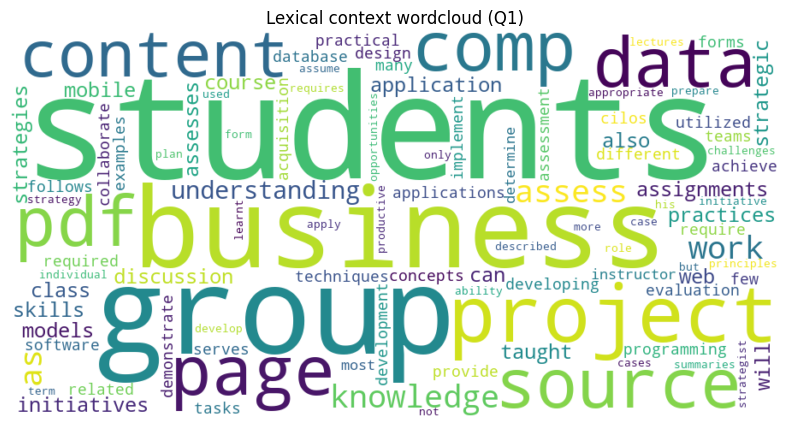

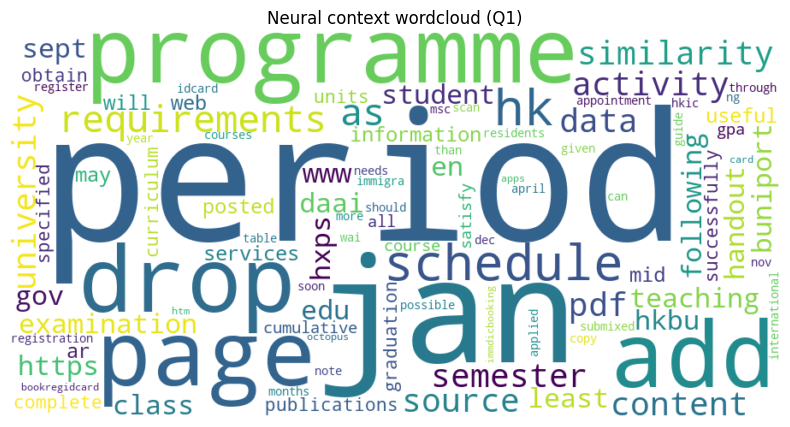

In [108]:
# Creates two wordclouds for a chosen query (default: Q1).

import matplotlib.pyplot as plt
from collections import Counter


def _clean_words(text: str):
    text = text.lower()
    words = re.findall(r"[a-z]{2,}", text)
    stop = {
        "the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
    "of", "to", "for", "and", "or", "in", "on", "at", "with", "by", "about",
    "what", "how", "why", "when", "where", "which", "who", "whom", "whose",
    "this", "that", "these", "those", "it", "they", "we", "you", "he", "she",
    "it", "them", "us", "him", "her", "its", "their", "our", "your"
    }
    return [w for w in words if w not in stop]


def plot_wordcloud_or_bars(title: str, text: str):
    words = _clean_words(text)
    freq = Counter(words)

    try:
        from wordcloud import WordCloud

        wc = WordCloud(width=900, height=450, background_color="white").generate_from_frequencies(freq)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()
    except Exception:
        top = freq.most_common(15)
        labels = [x[0] for x in top]
        vals = [x[1] for x in top]
        plt.figure(figsize=(10, 4))
        plt.bar(labels, vals)
        plt.xticks(rotation=45, ha="right")
        plt.title(title + " (top words)")
        plt.tight_layout()
        plt.show()


# Use Q1 results for visualization
r0 = results[0]
plot_wordcloud_or_bars("Lexical context wordcloud (Q1)", r0["lex_ctx"])
plot_wordcloud_or_bars("Neural context wordcloud (Q1)", r0["neu_ctx"])


## Quality, Token usage and Top_k tradeoff

This section evaluates how different `top_k` values affect:
- **Token usage** (approx context tokens)
- **Quality** (LLM-as-judge per-criterion scores + computed overall)

Run this after the main 3-query pipeline.


In [109]:
# --- Optional: top_k tradeoff (minimal version) ---
# Goal: produce data for three plots:
# - quality vs token-usage
# - quality vs top_k
# - token-usage vs top_k

import pandas as pd


def run_topk_tradeoff(rag, query: str, top_ks=(1, 2, 3, 5), max_chars_context: int = 1800):
    rows = []

    for k in map(int, top_ks):
        lex_ctx, _ = retrieve_context(rag, "lexical", query, top_k=k, max_chars=max_chars_context)
        neu_ctx, _ = retrieve_context(rag, "neural", query, top_k=k, max_chars=max_chars_context)

        ans_lex = answer_with_rag_and_citations(query, lex_ctx, model=GEN_MODEL)
        ans_neu = answer_with_rag_and_citations(query, neu_ctx, model=GEN_MODEL)

        verdict = judge_pairwise(query, ans_lex, ans_neu, model=JUDGE_MODEL)

        if isinstance(verdict, dict) and not verdict.get("parse_error"):
            a = verdict.get("A", {})
            b = verdict.get("B", {})
            lex_overall = overall_accuracy(a)
            neu_overall = overall_accuracy(b)
        else:
            lex_overall = None
            neu_overall = None

        rows.append(
            {
                "retriever": "lexical",
                "top_k": k,
                "ctx_tokens_approx": approx_tokens_from_chars(lex_ctx),
                "overall_accuracy": None if lex_overall is None else round(float(lex_overall), 2),
            }
        )
        rows.append(
            {
                "retriever": "neural",
                "top_k": k,
                "ctx_tokens_approx": approx_tokens_from_chars(neu_ctx),
                "overall_accuracy": None if neu_overall is None else round(float(neu_overall), 2),
            }
        )

    return pd.DataFrame(rows).sort_values(["retriever", "top_k"]).reset_index(drop=True)


tradeoff_df = run_topk_tradeoff(rag, query=Q1, top_ks=(1, 2, 3, 5), max_chars_context=1800)
tradeoff_df


,retriever,top_k,ctx_tokens_approx,overall_accuracy
0,lexical,1,132,4.25
1,lexical,2,268,3.50
2,lexical,3,399,4.25
3,lexical,5,450,3.50
4,neural,1,144,4.25
5,neural,2,283,3.25
6,neural,3,379,3.50
7,neural,5,450,3.00


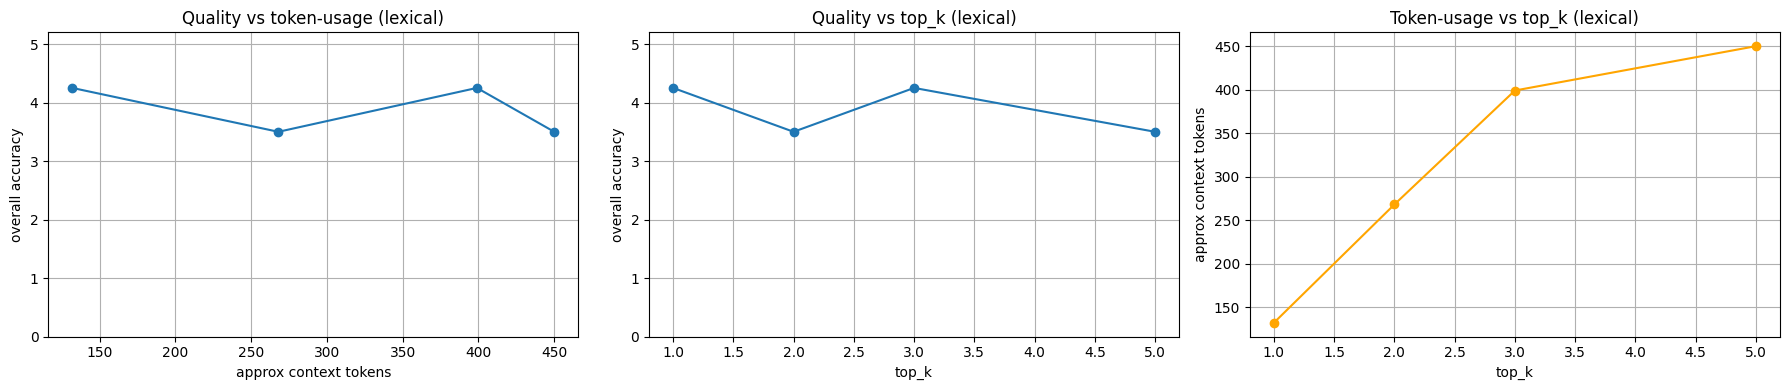

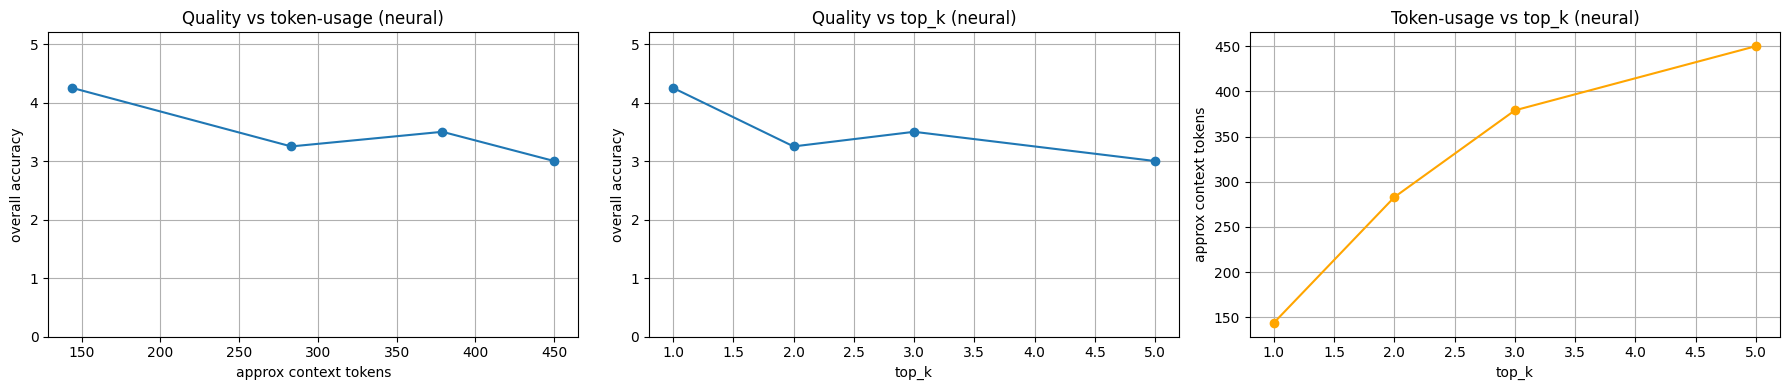

In [110]:
import matplotlib.pyplot as plt

# Uses `tradeoff_df` from the previous cell.

def plot_tradeoff_row(df, retriever: str):
    sub = df[df["retriever"] == retriever].sort_values("top_k")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # 1) quality vs token-usage
    axes[0].plot(sub["ctx_tokens_approx"], sub["overall_accuracy"], marker="o")
    axes[0].set_title(f"Quality vs token-usage ({retriever})")
    axes[0].set_xlabel("approx context tokens")
    axes[0].set_ylabel("overall accuracy")
    axes[0].set_ylim(0, 5.2)
    axes[0].grid(True)

    # 2) quality vs top_k
    axes[1].plot(sub["top_k"], sub["overall_accuracy"], marker="o")
    axes[1].set_title(f"Quality vs top_k ({retriever})")
    axes[1].set_xlabel("top_k")
    axes[1].set_ylabel("overall accuracy")
    axes[1].set_ylim(0, 5.2)
    axes[1].grid(True)

    # 3) token-usage vs top_k
    axes[2].plot(sub["top_k"], sub["ctx_tokens_approx"], marker="o", color="orange")
    axes[2].set_title(f"Token-usage vs top_k ({retriever})")
    axes[2].set_xlabel("top_k")
    axes[2].set_ylabel("approx context tokens")
    axes[2].grid(True)

    fig.tight_layout()
    plt.show()


plot_tradeoff_row(tradeoff_df, "lexical")
plot_tradeoff_row(tradeoff_df, "neural")
